<h1> Preparación de datos </h1>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

In [19]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

In [20]:
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')

<h1> Métricas de Producto (Visitas) </h1>

In [21]:
visits['session_year']  = visits['start_ts'].dt.year
visits['session_month'] = visits['start_ts'].dt.month
cv_month = visits['start_ts'].dt.to_period('M')
visits['session_week']  = visits['start_ts'].dt.isocalendar().week
visits['session_date']  = visits['start_ts'].dt.date

In [22]:
dau = visits.groupby('session_date').agg({'uid': 'nunique'}).mean()
wau = visits.groupby(['session_year', 'session_week']).agg({'uid': 'nunique'}).mean()
mau = visits.groupby(['session_year', 'session_month']).agg({'uid': 'nunique'}).mean()

In [37]:
visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
asl = visits['duration_sec'].mode()

In [36]:
sessions_per_user = visits.groupby('session_date').agg({'uid': ['count', 'nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']

In [35]:
first_visit_month = visits.groupby('uid')['start_ts'].min().dt.to_period('M').reset_index()
first_visit_month.columns = ['uid', 'first_visit_month']
visits_with_cohorts = visits.merge(first_visit_month, on='uid')

<h1> Métricas de Ventas y Cohortes </h1>

In [25]:
first_order_dates = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order_dates.columns = ['uid', 'first_order_month']
first_order_dates['first_order_month'] = first_order_dates['first_order_month'].dt.to_period('M')

In [26]:
orders_merged = pd.merge(orders, first_order_dates, on='uid')
orders_merged['order_month'] = orders_merged['buy_ts'].dt.to_period('M')

In [27]:
cohorts = orders_merged.groupby(['first_order_month', 'order_month']).agg({'revenue': 'sum', 'uid': 'nunique'}).reset_index()
cohorts['age'] = (cohorts['order_month'].astype(int) - cohorts['first_order_month'].astype(int))

In [11]:
cohort_sizes = first_order_dates.groupby('first_order_month').agg({'uid': 'count'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

report = pd.merge(cohorts, cohort_sizes, on='first_order_month')
report['ltv'] = report['revenue'] / report['n_buyers']

In [12]:
ltv_pivot = report.pivot_table(index='first_order_month', columns='age', values='ltv', aggfunc='sum').cumsum(axis=1)

In [33]:
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()

conversion_time = first_visit.merge(first_order, on='uid')
conversion_time['days_to_purchase'] = (conversion_time['buy_ts'] - conversion_time['start_ts']).dt.days

Text(0, 0.5, 'Usuarios')

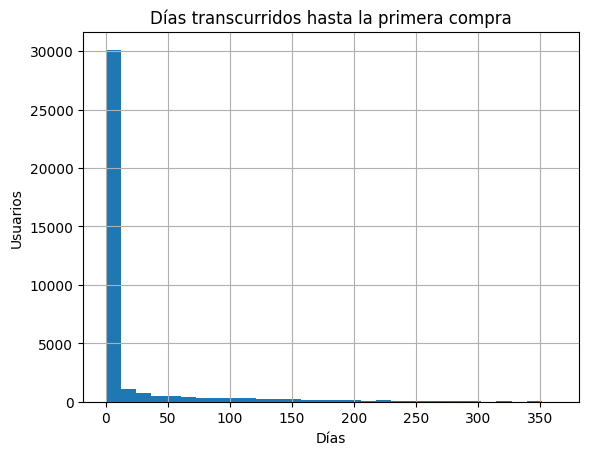

In [34]:
conversion_time['days_to_purchase'].hist(bins=30)
plt.title('Días transcurridos hasta la primera compra')
plt.xlabel('Días')
plt.ylabel('Usuarios')

<h1> Métricas de Marketing (CAC y ROMI) </h1>

In [13]:
costs['month'] = costs['dt'].dt.to_period('M')
monthly_costs = costs.groupby('month').agg({'costs': 'sum'}).reset_index()

In [14]:
report_marketing = pd.merge(report, monthly_costs, left_on='first_order_month', right_on='month')
report_marketing['cac'] = report_marketing['costs'] / report_marketing['n_buyers']

In [15]:
report_marketing['romi'] = report_marketing['ltv'] / report_marketing['cac']

In [16]:
source_costs = costs.groupby('source_id').agg({'costs': 'sum'}).reset_index()
source_orders = pd.merge(orders, visits[['uid', 'source_id']], on='uid').drop_duplicates()

In [38]:
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
order_size = orders.groupby('order_month').agg({'revenue': 'sum', 'uid': 'count'})
order_size['aov'] = order_size['revenue'] / order_size['uid']

In [39]:
user_source = visits.sort_values('start_ts').groupby('uid').first()[['source_id', 'device']].reset_index()
orders_by_source = orders.merge(user_source, on='uid')

rev_device = orders_by_source.groupby('device')['revenue'].sum()

source_costs = costs.groupby('source_id')['costs'].sum()
source_users = user_source.groupby('source_id')['uid'].count()
cac_source = source_costs / source_users

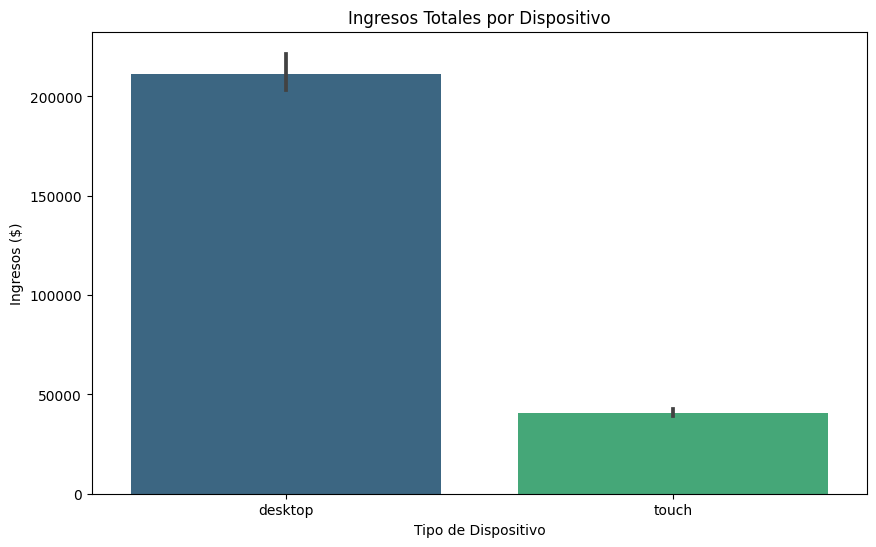

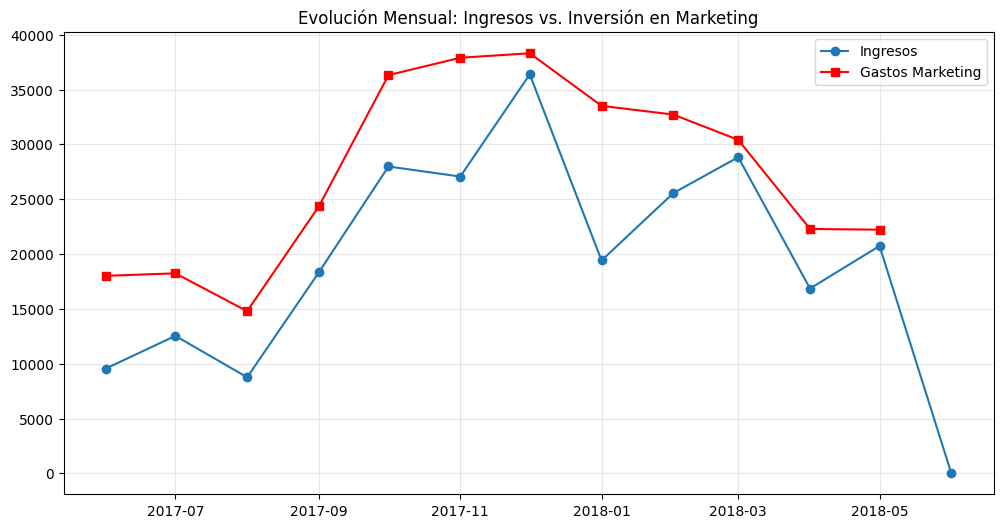

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1.1 Comparación de Ingresos por Dispositivo ---
plt.figure(figsize=(10, 6))
sns.barplot(data=orders_by_source, x='device', y='revenue', estimator=sum, palette='viridis')
plt.title('Ingresos Totales por Dispositivo')
plt.ylabel('Ingresos ($)')
plt.xlabel('Tipo de Dispositivo')
plt.show()

# --- 1.2 Tendencia Temporal de Gastos vs Ingresos ---
monthly_revenue = orders.groupby('order_month')['revenue'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].dt.to_timestamp()
monthly_costs['month_ts'] = monthly_costs['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['order_month'], monthly_revenue['revenue'], label='Ingresos', marker='o')
plt.plot(monthly_costs['month_ts'], monthly_costs['costs'], label='Gastos Marketing', marker='s', color='red')
plt.title('Evolución Mensual: Ingresos vs. Inversión en Marketing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

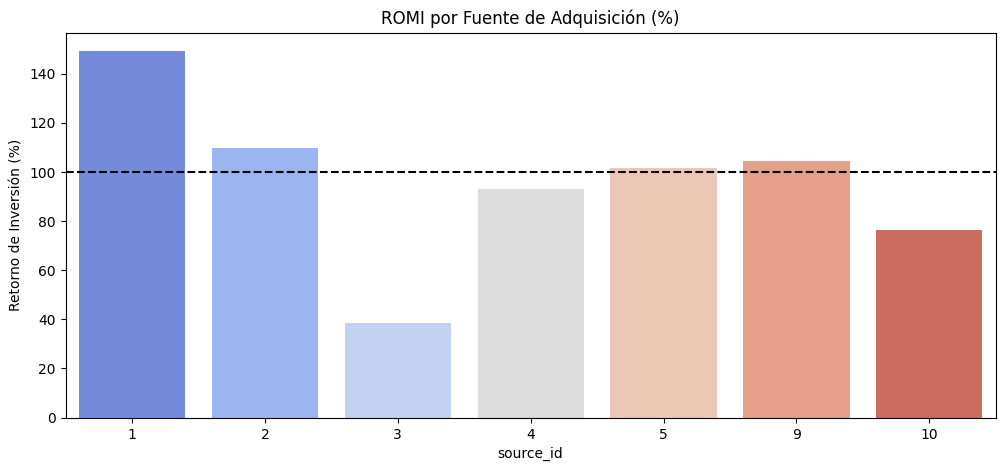

In [41]:
# Unir costos con ingresos atribuidos por fuente
source_performance = orders_by_source.groupby('source_id').agg({'revenue': 'sum', 'uid': 'nunique'})
source_performance = source_performance.merge(source_costs, on='source_id')
source_performance['cac'] = source_performance['costs'] / source_performance['uid']
source_performance['romi'] = (source_performance['revenue'] / source_performance['costs']) * 100

# Visualización del ROMI por Fuente
plt.figure(figsize=(12, 5))
sns.barplot(data=source_performance.reset_index(), x='source_id', y='romi', palette='coolwarm')
plt.axhline(100, color='black', linestyle='--') # Punto de equilibrio
plt.title('ROMI por Fuente de Adquisición (%)')
plt.ylabel('Retorno de Inversión (%)')
plt.show()

In [42]:
print("=== RESUMEN EJECUTIVO ===")
print(f"DAU promedio: {dau.iloc[0]:.0f} usuarios")
print(f"Mejor fuente por ROMI: {source_performance['romi'].idxmax()}")
print(f"Dispositivo con más ingresos: {rev_device.idxmax()}")

print("\n=== RECOMENDACIONES ===")
print("1. Enfocar presupuesto en fuentes con ROMI > 100%")
print("2. Optimizar experiencia móvil si desktop genera más ingresos")
print("3. Mejorar retención en primeros 30 días post-compra")

=== RESUMEN EJECUTIVO ===
DAU promedio: 908 usuarios
Mejor fuente por ROMI: 1
Dispositivo con más ingresos: desktop

=== RECOMENDACIONES ===
1. Enfocar presupuesto en fuentes con ROMI > 100%
2. Optimizar experiencia móvil si desktop genera más ingresos
3. Mejorar retención en primeros 30 días post-compra


Observe que la mayoría de los usuarios compran en el día 0. Esto indica que el servicio es impulsivo o que los usuarios ya vienen decididos desde el anuncio.
